# Preprocessing: Diabetes Health Indicators Dataset (BRFSS 2015)

**Dataset:** `diabetes_012_health_indicators_BRFSS2015.csv`  
**Source:** [Kaggle - Alex Teboul](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset)

---

### Alur Preprocessing:

1. Load Dataset & Inspeksi Awal  
2. Pemahaman Fitur (Data Dictionary)  
3. Kategorisasi Jenis Fitur  
   - Binary Features  
   - Ordinal Features  
   - Continuous Features  

4. Pengecekan Missing Values  
5. Pengecekan Data Duplikat  
6. Analisis Distribusi Data  
7. Analisis Outlier  
8. Penanganan Outlier (BMI Only - IQR Capping)  
9. Optimasi & Konversi Tipe Data  
10. Pemisahan Dataset  
    - `df_privacy` untuk SCDP/ACDP-Tree  
    - `df_ml` untuk Machine Learning  

11. Definisi Role Attribute  
    - Identifier Attributes  
    - Quasi-Identifier Attributes  
    - Sensitive Attribute  
    - Non-Sensitive Attributes  

12. Attribute Generalization  
    - Age Generalization  
    - BMI Generalization  
    - Income Generalization  
    - Education Generalization  
    - General Health Generalization  

13. Penyimpanan Dataset Hasil Preprocessing

## 0️⃣ Install & Import Library

In [37]:
!pip install imbalanced-learn -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

## 📂 Upload Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

Saving diabetes_012_health_indicators_BRFSS2015.csv to diabetes_012_health_indicators_BRFSS2015 (1).csv


---
## 1️⃣ Inspeksi Awal Dataset

In [ ]:
print('=' * 60)
print(f'SHAPE     : {df.shape[0]:,} baris x {df.shape[1]} kolom')
print('=' * 60)
df.head()

SHAPE     : 253,680 baris x 22 kolom


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0000,1.0000,1.0000,1.0000,40.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,5.0000,18.0000,15.0000,1.0000,0.0000,9.0000,4.0000,3.0000
1,0.0000,0.0000,0.0000,0.0000,25.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,3.0000,0.0000,0.0000,0.0000,0.0000,7.0000,6.0000,1.0000
2,0.0000,1.0000,1.0000,1.0000,28.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,5.0000,30.0000,30.0000,1.0000,0.0000,9.0000,4.0000,8.0000
3,0.0000,1.0000,0.0000,1.0000,27.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,2.0000,0.0000,0.0000,0.0000,0.0000,11.0000,3.0000,6.0000
4,0.0000,1.0000,1.0000,1.0000,24.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,2.0000,3.0000,0.0000,0.0000,0.0000,11.0000,5.0000,4.0000


In [ ]:
print('Tipe Data & Non-Null Count:')
df.info()

Tipe Data & Non-Null Count:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               25

In [ ]:
print('Statistik Deskriptif:')
df.describe().T

Statistik Deskriptif:


,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0000,0.2969,0.6982,0.0000,0.0000,0.0000,0.0000,2.0000
HighBP,253680.0000,0.4290,0.4949,0.0000,0.0000,0.0000,1.0000,1.0000
HighChol,253680.0000,0.4241,0.4942,0.0000,0.0000,0.0000,1.0000,1.0000
CholCheck,253680.0000,0.9627,0.1896,0.0000,1.0000,1.0000,1.0000,1.0000
BMI,253680.0000,28.3824,6.6087,12.0000,24.0000,27.0000,31.0000,98.0000
Smoker,253680.0000,0.4432,0.4968,0.0000,0.0000,0.0000,1.0000,1.0000
Stroke,253680.0000,0.0406,0.1973,0.0000,0.0000,0.0000,0.0000,1.0000
HeartDiseaseorAttack,253680.0000,0.0942,0.2921,0.0000,0.0000,0.0000,0.0000,1.0000
PhysActivity,253680.0000,0.7565,0.4292,0.0000,1.0000,1.0000,1.0000,1.0000
Fruits,253680.0000,0.6343,0.4816,0.0000,0.0000,1.0000,1.0000,1.0000


---
## 2️⃣ Data Dictionary & Tipe Fitur

Klasifikasi fitur berdasarkan jenisnya:

In [ ]:
data_dict = {
    'Kolom': [
        'Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
        'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity',
        'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
        'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth',
        'DiffWalk', 'Sex', 'Age', 'Education', 'Income'
    ],
    'Deskripsi': [
        'Target: 0=No diabetes, 1=Prediabetes, 2=Diabetes',
        'Tekanan darah tinggi (0=Tidak, 1=Ya)',
        'Kolesterol tinggi (0=Tidak, 1=Ya)',
        'Cek kolesterol ≥5 tahun terakhir (0=Tidak, 1=Ya)',
        'Body Mass Index (numerik kontinu)',
        'Pernah merokok ≥100 batang seumur hidup (0=Tidak, 1=Ya)',
        'Pernah stroke (0=Tidak, 1=Ya)',
        'Penyakit jantung atau serangan jantung (0=Tidak, 1=Ya)',
        'Aktivitas fisik dalam 30 hari terakhir (0=Tidak, 1=Ya)',
        'Konsumsi buah ≥1x sehari (0=Tidak, 1=Ya)',
        'Konsumsi sayur ≥1x sehari (0=Tidak, 1=Ya)',
        'Konsumsi alkohol berat (0=Tidak, 1=Ya)',
        'Memiliki asuransi kesehatan (0=Tidak, 1=Ya)',
        'Tidak periksa dokter karena biaya (0=Tidak, 1=Ya)',
        'Kesehatan umum: 1=Sangat Baik s.d. 5=Buruk (ordinal)',
        'Hari kesehatan mental buruk (0-30 hari)',
        'Hari kesehatan fisik buruk (0-30 hari)',
        'Kesulitan berjalan/naik tangga (0=Tidak, 1=Ya)',
        'Jenis kelamin (0=Perempuan, 1=Laki-laki)',
        'Kelompok usia (1=18-24 s.d. 13=80+) ordinal',
        'Tingkat pendidikan (1-6) ordinal',
        'Tingkat pendapatan (1-8) ordinal'
    ],
    'Tipe': [
        'Target (Multiclass)', 'Biner', 'Biner', 'Biner', 'Kontinu',
        'Biner', 'Biner', 'Biner', 'Biner',
        'Biner', 'Biner', 'Biner', 'Biner',
        'Biner', 'Ordinal', 'Kontinu', 'Kontinu',
        'Biner', 'Biner', 'Ordinal', 'Ordinal', 'Ordinal'
    ]
}

dict_df = pd.DataFrame(data_dict)
print('Data Dictionary:')
dict_df.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white')]}]
)

Data Dictionary:


,Kolom,Deskripsi,Tipe
0,Diabetes_012,"Target: 0=No diabetes, 1=Prediabetes, 2=Diabetes",Target (Multiclass)
1,HighBP,"Tekanan darah tinggi (0=Tidak, 1=Ya)",Biner
2,HighChol,"Kolesterol tinggi (0=Tidak, 1=Ya)",Biner
3,CholCheck,"Cek kolesterol ≥5 tahun terakhir (0=Tidak, 1=Ya)",Biner
4,BMI,Body Mass Index (numerik kontinu),Kontinu
5,Smoker,"Pernah merokok ≥100 batang seumur hidup (0=Tidak, 1=Ya)",Biner
6,Stroke,"Pernah stroke (0=Tidak, 1=Ya)",Biner
7,HeartDiseaseorAttack,"Penyakit jantung atau serangan jantung (0=Tidak, 1=Ya)",Biner
8,PhysActivity,"Aktivitas fisik dalam 30 hari terakhir (0=Tidak, 1=Ya)",Biner
9,Fruits,"Konsumsi buah ≥1x sehari (0=Tidak, 1=Ya)",Biner


In [ ]:
TARGET = 'Diabetes_012'

BINARY_FEATURES = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex'
]

ORDINAL_FEATURES = ['GenHlth', 'Age', 'Education', 'Income']

CONTINUOUS_FEATURES = ['BMI', 'MentHlth', 'PhysHlth']

print(f'Target       : {TARGET}')
print(f'Biner        : {len(BINARY_FEATURES)} fitur → {BINARY_FEATURES}')
print(f'Ordinal      : {len(ORDINAL_FEATURES)} fitur → {ORDINAL_FEATURES}')
print(f'Kontinu      : {len(CONTINUOUS_FEATURES)} fitur → {CONTINUOUS_FEATURES}')

Target       : Diabetes_012
Biner        : 14 fitur → ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
Ordinal      : 4 fitur → ['GenHlth', 'Age', 'Education', 'Income']
Kontinu      : 3 fitur → ['BMI', 'MentHlth', 'PhysHlth']


---
## 3️⃣ Pengecekan Missing Values

In [ ]:
missing = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase (%)': (df.isnull().sum() / len(df) * 100).round(2)
})

if missing['Jumlah Missing'].sum() == 0:
    print('Tidak ada missing values dalam dataset ini!')
else:
    print('Kolom dengan missing values:')
    print(missing[missing['Jumlah Missing'] > 0])

    plt.figure(figsize=(10, 4))
    missing[missing['Jumlah Missing'] > 0]['Persentase (%)'].plot(kind='bar', color='tomato')
    plt.title('Persentase Missing Values per Kolom')
    plt.ylabel('Persentase (%)')
    plt.tight_layout()
    plt.show()

missing

Tidak ada missing values dalam dataset ini!


,Jumlah Missing,Persentase (%)
Diabetes_012,0,0.0000
HighBP,0,0.0000
HighChol,0,0.0000
CholCheck,0,0.0000
BMI,0,0.0000
Smoker,0,0.0000
Stroke,0,0.0000
HeartDiseaseorAttack,0,0.0000
PhysActivity,0,0.0000
Fruits,0,0.0000


---
## 4️⃣ Pengecekan & Penghapusan Duplikat

In [ ]:
n_duplikat = df.duplicated().sum()
print(f'Jumlah baris duplikat: {n_duplikat:,}')
print(f'   Persentase           : {n_duplikat/len(df)*100:.2f}%')

if n_duplikat > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Duplikat dihapus. Shape baru: {df.shape}')
else:
    print('Tidak ada duplikat ditemukan.')

Jumlah baris duplikat: 23,899
   Persentase           : 9.42%
Duplikat dihapus. Shape baru: (229781, 22)


---
## 5️⃣ Analisis Distribusi & Target

Distribusi Kelas Target (Diabetes_012):
                    Label  Jumlah  Persentase %
Diabetes_012                                   
0.0000        No Diabetes  190055       82.7100
1.0000        Prediabetes    4629        2.0100
2.0000           Diabetes   35097       15.2700


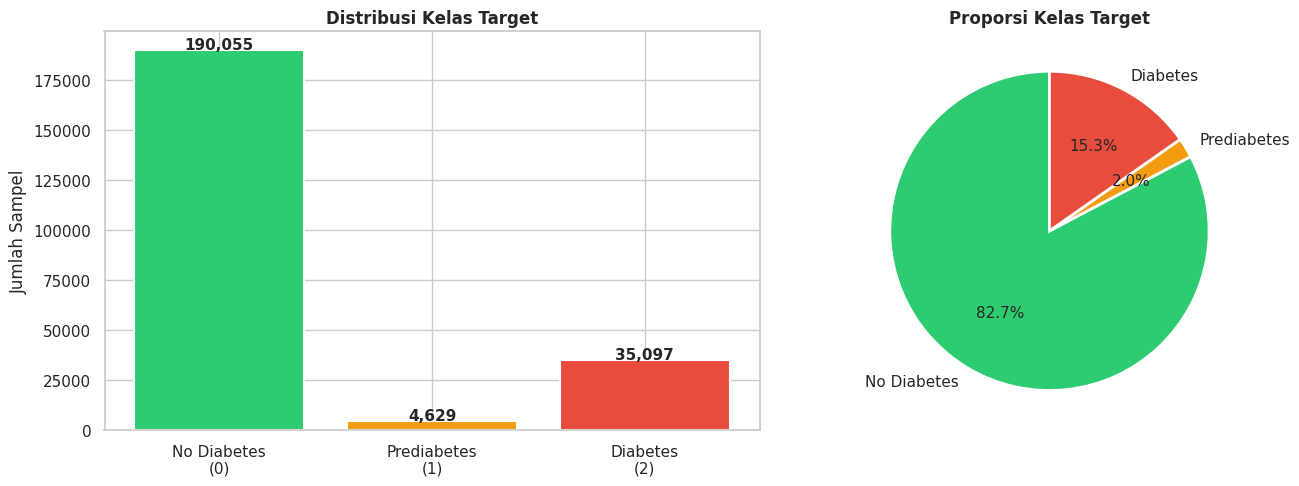

In [ ]:
target_counts = df[TARGET].value_counts().sort_index()
target_pct    = df[TARGET].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    'Label'       : ['No Diabetes', 'Prediabetes', 'Diabetes'],
    'Jumlah'      : target_counts.values,
    'Persentase %': target_pct.values.round(2)
}, index=target_counts.index)

print('Distribusi Kelas Target (Diabetes_012):')
print(target_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#f39c12', '#e74c3c']

axes[0].bar(['No Diabetes\n(0)', 'Prediabetes\n(1)', 'Diabetes\n(2)'],
            target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Kelas Target', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=['No Diabetes', 'Prediabetes', 'Diabetes'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas Target', fontweight='bold')

plt.tight_layout()
plt.show()

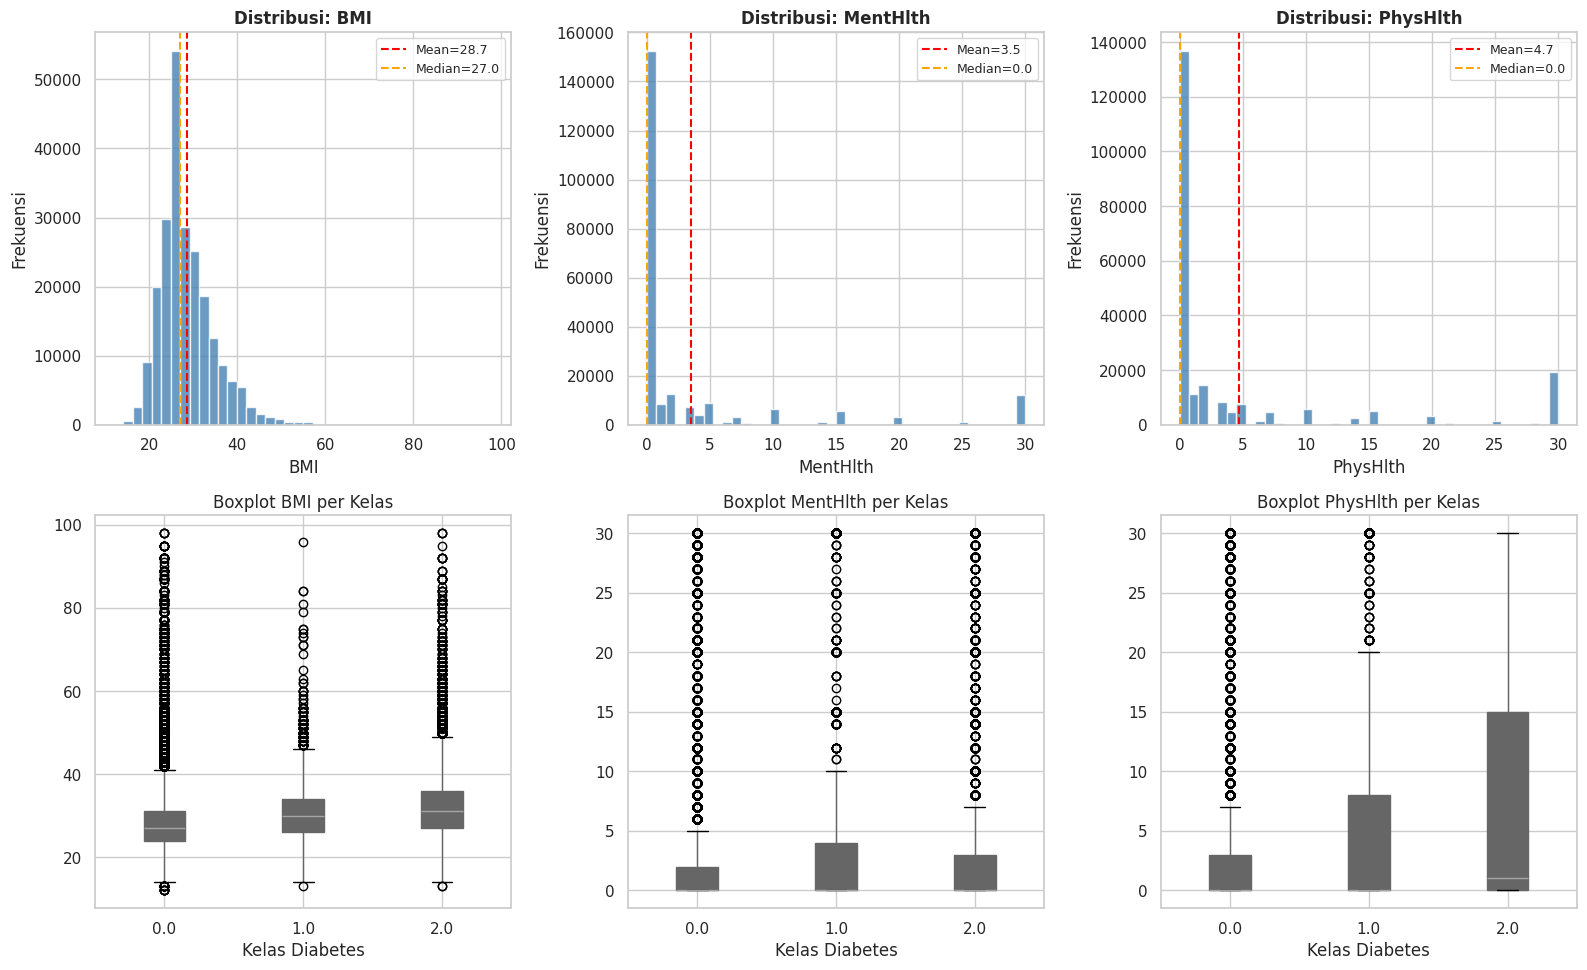

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(CONTINUOUS_FEATURES):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribusi: {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--', label=f'Mean={df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', label=f'Median={df[col].median():.1f}')
    axes[i].legend(fontsize=9)

for j, col in enumerate(CONTINUOUS_FEATURES):
    ax = axes[3 + j]
    df.boxplot(column=col, by=TARGET, ax=ax, patch_artist=True)
    ax.set_title(f'Boxplot {col} per Kelas', fontweight='bold')
    ax.set_xlabel('Kelas Diabetes')
    plt.sca(ax)
    plt.title(f'Boxplot {col} per Kelas')

plt.suptitle('')
plt.tight_layout()
plt.show()

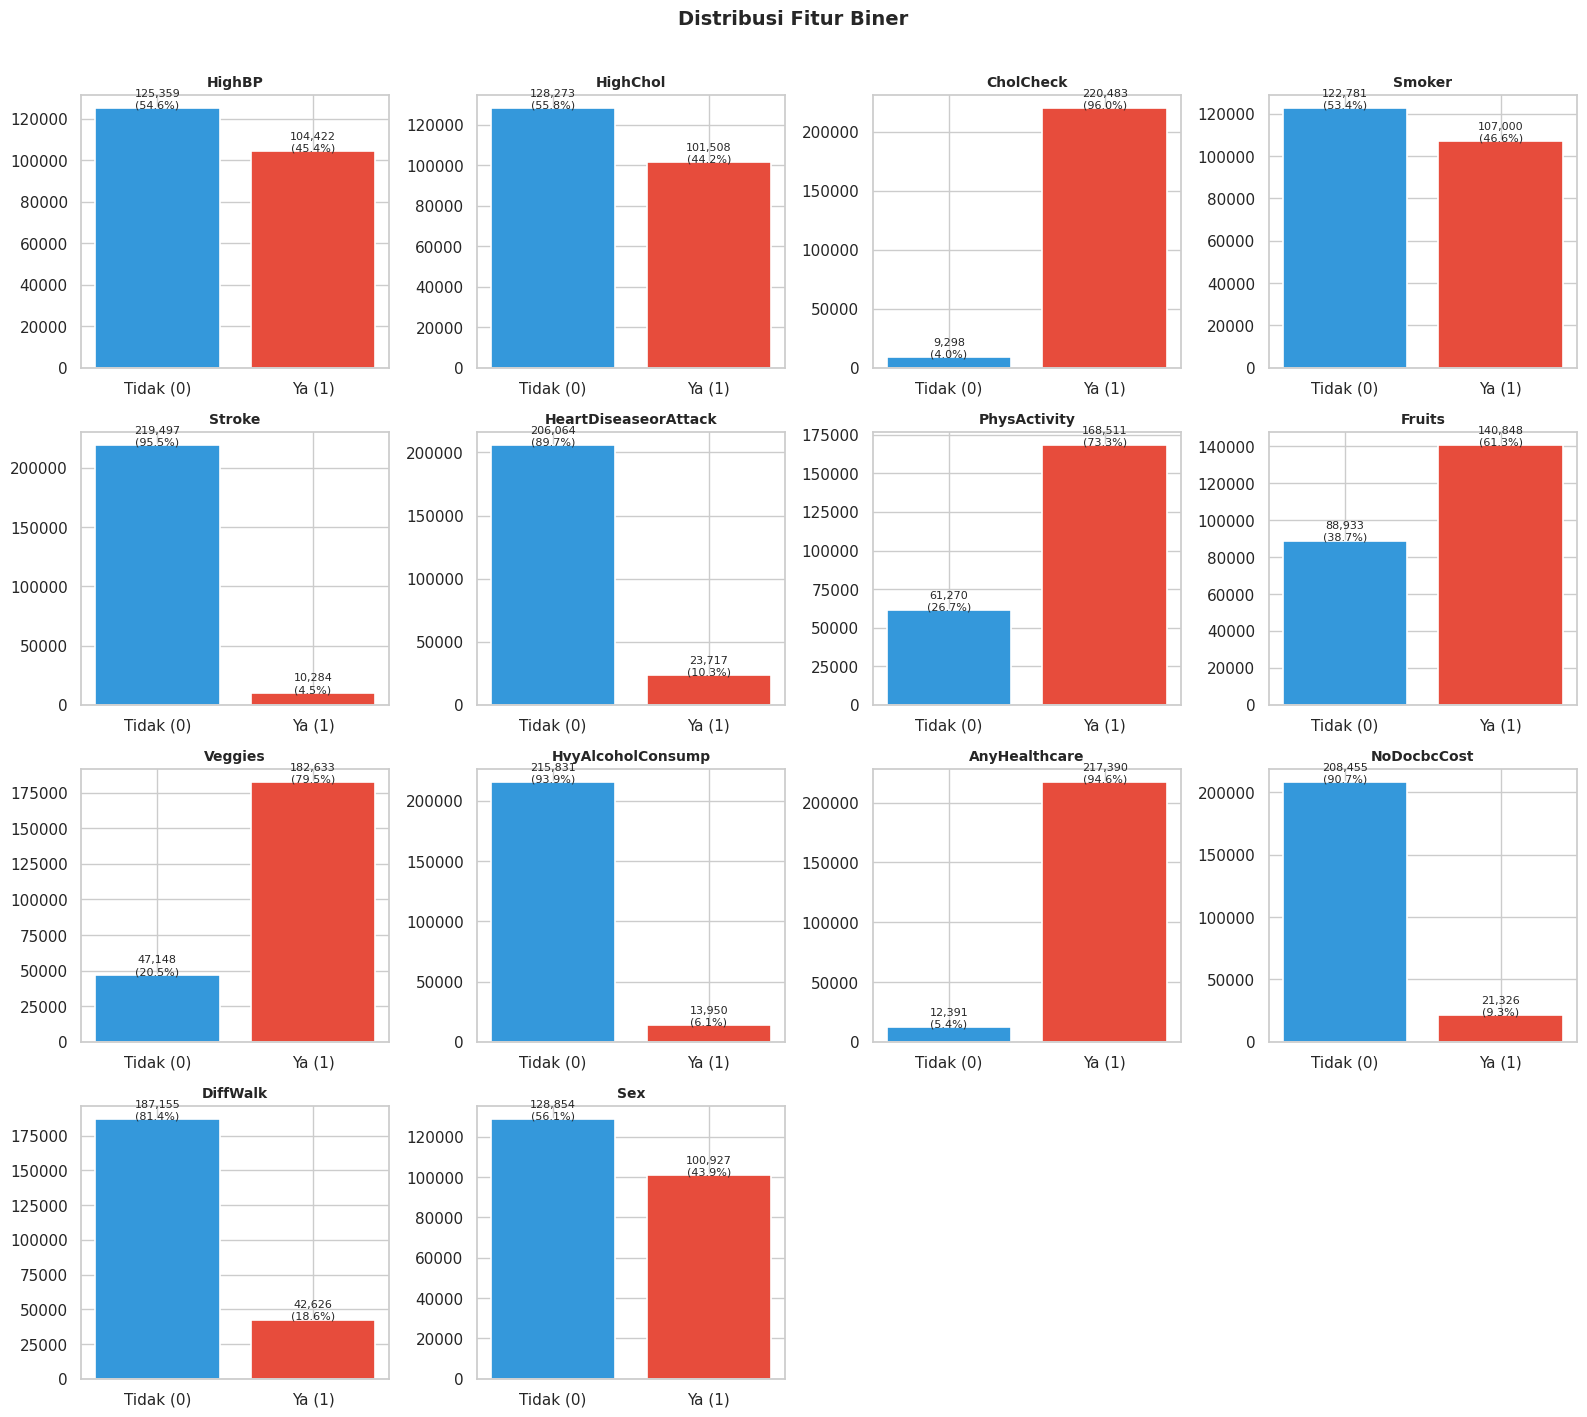

In [ ]:
n_cols = 4
n_rows = (len(BINARY_FEATURES) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(BINARY_FEATURES):
    val_counts = df[col].value_counts().sort_index()
    axes[i].bar(['Tidak (0)', 'Ya (1)'], val_counts.values,
                color=['#3498db', '#e74c3c'], edgecolor='white', linewidth=1.2)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    for k, v in enumerate(val_counts.values):
        axes[i].text(k, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Biner', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6️⃣ Deteksi & Penanganan Outlier (Fitur Kontinu)

In [ ]:
def detect_outliers_iqr(df, columns):
    """Deteksi outlier menggunakan metode IQR"""
    results = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        results.append({
            'Fitur'       : col,
            'Q1'          : round(Q1, 2),
            'Q3'          : round(Q3, 2),
            'IQR'         : round(IQR, 2),
            'Batas Bawah' : round(lower, 2),
            'Batas Atas'  : round(upper, 2),
            'Jml Outlier' : n_out,
            'Pct Outlier%': round(n_out / len(df) * 100, 2)
        })
    return pd.DataFrame(results)

outlier_report = detect_outliers_iqr(df, CONTINUOUS_FEATURES)
print('Laporan Outlier (Metode IQR):')
outlier_report

Laporan Outlier (Metode IQR):


,Fitur,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jml Outlier,Pct Outlier%
0,BMI,24.0000,32.0000,8.0000,12.0000,44.0000,5638,2.4500
1,MentHlth,0.0000,2.0000,2.0000,-3.0000,5.0000,36163,15.7400
2,PhysHlth,0.0000,4.0000,4.0000,-6.0000,10.0000,34347,14.9500


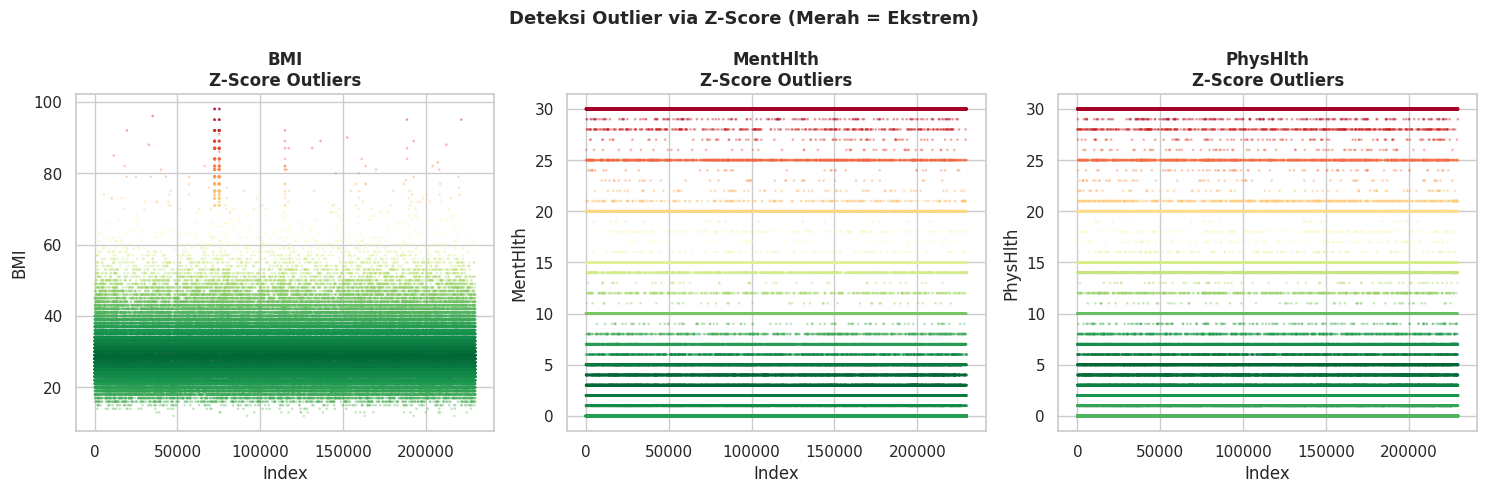

In [ ]:
fig, axes = plt.subplots(1, len(CONTINUOUS_FEATURES), figsize=(15, 5))

for i, col in enumerate(CONTINUOUS_FEATURES):
    z_scores = np.abs(stats.zscore(df[col]))
    axes[i].scatter(range(len(df)), df[col], c=z_scores, cmap='RdYlGn_r',
                    alpha=0.3, s=1)
    axes[i].set_title(f'{col}\nZ-Score Outliers', fontweight='bold')
    axes[i].set_xlabel('Index')
    axes[i].set_ylabel(col)

plt.suptitle('Deteksi Outlier via Z-Score (Merah = Ekstrem)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
OUTLIER_FEATURES = ['BMI']

df_clean = df.copy()

for col in OUTLIER_FEATURES:
    Q1    = df_clean[col].quantile(0.25)
    Q3    = df_clean[col].quantile(0.75)
    IQR   = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # clipping / winsorizing
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

    print(f' {col}: clipping ke [{lower:.2f}, {upper:.2f}]')

print(f'\nShape setelah capping: {df_clean.shape}')

 BMI: clipping ke [12.00, 44.00]

Shape setelah capping: (229781, 22)


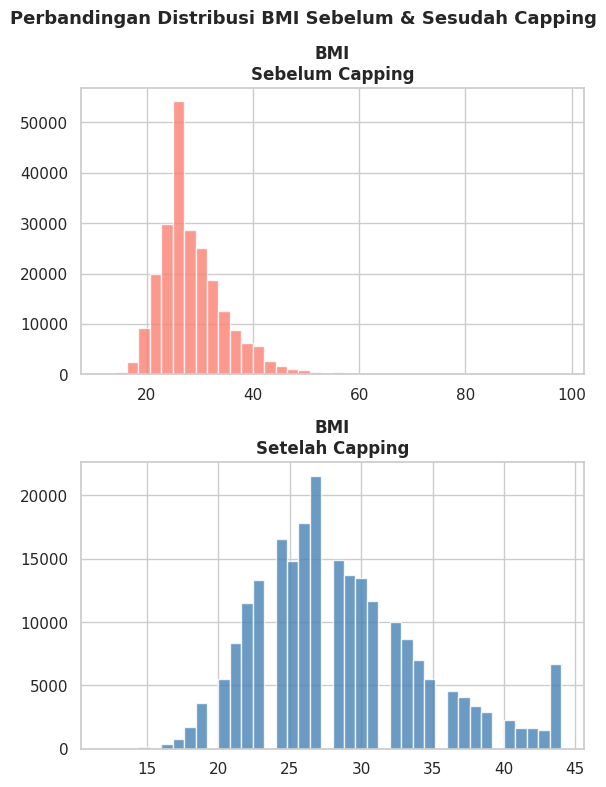

In [ ]:
fig, axes = plt.subplots(2, len(OUTLIER_FEATURES), figsize=(6, 8))

if len(OUTLIER_FEATURES) == 1:
    axes = np.array(axes).reshape(2,1)

for i, col in enumerate(OUTLIER_FEATURES):

    axes[0, i].hist(
        df[col],
        bins=40,
        color='salmon',
        edgecolor='white',
        alpha=0.8
    )
    axes[0, i].set_title(
        f'{col}\nSebelum Capping',
        fontweight='bold'
    )

    axes[1, i].hist(
        df_clean[col],
        bins=40,
        color='steelblue',
        edgecolor='white',
        alpha=0.8
    )
    axes[1, i].set_title(
        f'{col}\nSetelah Capping',
        fontweight='bold'
    )

plt.suptitle(
    'Perbandingan Distribusi BMI Sebelum & Sesudah Capping',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

---
## 7️⃣ Encoding Fitur Kategorikal

In [ ]:
for col in BINARY_FEATURES:
    df_clean[col] = df_clean[col].astype('int8')

for col in ORDINAL_FEATURES:
    df_clean[col] = df_clean[col].astype('int8')

df_clean[TARGET] = df_clean[TARGET].astype('int8')

print(' Tipe data setelah konversi:')
print(df_clean.dtypes)
print(f'\n Penggunaan memori: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

 Tipe data setelah konversi:
Diabetes_012               int8
HighBP                     int8
HighChol                   int8
CholCheck                  int8
BMI                     float64
Smoker                     int8
Stroke                     int8
HeartDiseaseorAttack       int8
PhysActivity               int8
Fruits                     int8
Veggies                    int8
HvyAlcoholConsump          int8
AnyHealthcare              int8
NoDocbcCost                int8
GenHlth                    int8
MentHlth                float64
PhysHlth                float64
DiffWalk                   int8
Sex                        int8
Age                        int8
Education                  int8
Income                     int8
dtype: object

 Penggunaan memori: 9.42 MB


In [ ]:
df_privacy = df_clean.copy()

df_ml = df_clean.copy()

print('Dataset dipisah:')
print(f'   df_privacy : {df_privacy.shape}')
print(f'   df_ml      : {df_ml.shape}')

Dataset dipisah:
   df_privacy : (229781, 22)
   df_ml      : (229781, 22)


---
## 9️⃣ Attribute Role Definition

In [ ]:
IDENTIFIER_ATTRIBUTES = []

QI_ATTRIBUTES = [
    'Age',
    'Sex',
    'Education',
    'Income',
    'BMI',
    'GenHlth'
]

SENSITIVE_ATTRIBUTE = 'Diabetes_012'

SENSITIVE_CANDIDATES = [
    'Diabetes_012',
    'HighBP',
    'HighChol',
    'HeartDiseaseorAttack',
    'Stroke'
]

NON_SENSITIVE_ATTRIBUTES = [
    'Smoker',
    'HvyAlcoholConsump',
    'PhysActivity',
    'Fruits',
    'Veggies',
    'MentHlth',
    'PhysHlth',
    'DiffWalk',
    'CholCheck',
    'AnyHealthcare',
    'NoDocbcCost'
]

print('Identifier Attributes:', IDENTIFIER_ATTRIBUTES)
print('Quasi-Identifier Attributes:', QI_ATTRIBUTES)
print('Sensitive Attribute:', SENSITIVE_ATTRIBUTE)
print('Non-Sensitive Attributes:', NON_SENSITIVE_ATTRIBUTES)

Identifier Attributes: []
Quasi-Identifier Attributes: ['Age', 'Sex', 'Education', 'Income', 'BMI', 'GenHlth']
Sensitive Attribute: Diabetes_012
Non-Sensitive Attributes: ['Smoker', 'HvyAlcoholConsump', 'PhysActivity', 'Fruits', 'Veggies', 'MentHlth', 'PhysHlth', 'DiffWalk', 'CholCheck', 'AnyHealthcare', 'NoDocbcCost']


---
## 🔟 Generalization

In [ ]:
# ================================
# AGE GENERALIZATION
# ================================

def generalize_age(x):

    if x <= 3:
        return 'Young'

    elif x <= 7:
        return 'Adult'

    elif x <= 10:
        return 'MiddleAge'

    else:
        return 'Senior'


df_privacy['Age_Group'] = df_privacy['Age'].apply(generalize_age)

print(df_privacy[['Age', 'Age_Group']].head())

   Age  Age_Group
0    9  MiddleAge
1    7      Adult
2    9  MiddleAge
3   11     Senior
4   11     Senior


In [ ]:
# ================================
# BMI GENERALIZATION
# ================================

def generalize_bmi(x):

    if x < 18.5:
        return 'Underweight'

    elif x < 25:
        return 'Normal'

    elif x < 30:
        return 'Overweight'

    else:
        return 'Obese'


df_privacy['BMI_Group'] = df_privacy['BMI'].apply(generalize_bmi)

print(df_privacy[['BMI', 'BMI_Group']].head())

      BMI   BMI_Group
0 40.0000       Obese
1 25.0000  Overweight
2 28.0000  Overweight
3 27.0000  Overweight
4 24.0000      Normal


In [ ]:
# ================================
# INCOME GENERALIZATION
# ================================

def generalize_income(x):

    if x <= 3:
        return 'Low'

    elif x <= 6:
        return 'Middle'

    else:
        return 'High'


df_privacy['Income_Group'] = df_privacy['Income'].apply(generalize_income)

print(df_privacy[['Income', 'Income_Group']].head())

   Income Income_Group
0       3          Low
1       1          Low
2       8         High
3       6       Middle
4       4       Middle


In [ ]:
# ================================
# EDUCATION GENERALIZATION
# ================================

def generalize_education(x):

    if x <= 2:
        return 'LowEdu'

    elif x <= 4:
        return 'MidEdu'

    else:
        return 'HighEdu'


df_privacy['Education_Group'] = df_privacy['Education'].apply(generalize_education)

print(df_privacy[['Education', 'Education_Group']].head())

   Education Education_Group
0          4          MidEdu
1          6         HighEdu
2          4          MidEdu
3          3          MidEdu
4          5         HighEdu


In [ ]:
# ================================
# GENERAL HEALTH GENERALIZATION
# ================================

def generalize_genhlth(x):

    if x <= 2:
        return 'Good'

    elif x == 3:
        return 'Fair'

    else:
        return 'Poor'


df_privacy['GenHlth_Group'] = df_privacy['GenHlth'].apply(generalize_genhlth)

print(df_privacy[['GenHlth', 'GenHlth_Group']].head())

   GenHlth GenHlth_Group
0        5          Poor
1        3          Fair
2        5          Poor
3        2          Good
4        2          Good


In [ ]:
generalized_cols = [
    'Age_Group',
    'BMI_Group',
    'Income_Group',
    'Education_Group',
    'GenHlth_Group'
]

df_privacy[generalized_cols].head()

,Age_Group,BMI_Group,Income_Group,Education_Group,GenHlth_Group
0,MiddleAge,Obese,Low,MidEdu,Poor
1,Adult,Overweight,Low,HighEdu,Fair
2,MiddleAge,Overweight,High,MidEdu,Poor
3,Senior,Overweight,Middle,MidEdu,Good
4,Senior,Normal,Middle,HighEdu,Good


---
## 1️⃣1️⃣ Simpan Preprocessing

In [ ]:
output_file = 'diabetes_preprocessed_privacy.csv'

df_privacy.to_csv(output_file, index=False)

print(f'Dataset preprocessing berhasil disimpan:')
print(f'{output_file}')

Dataset preprocessing berhasil disimpan:
diabetes_preprocessed_privacy.csv
